In [1]:
# load the correlation results
from general_utils import load_temporary_data

# path that you passed as   save_folder / (save_name + ".csv")
zarr_path = "/root/capsule/scratch/correlation_results/sig_dir_all_sessions.zarr"
ds = load_temporary_data(zarr_path)

print("Rows:", len(ds))
display(ds.head())             # in a notebook


Rows: 69951


,ARDL_model-ForagingCompareThreshold-RPE-g9-s-1-d0-coef,ARDL_model-ForagingCompareThreshold-RPE-g9-s-1-d0-pval,ARDL_model-ForagingCompareThreshold-RPE-g9-s-1-d0-tval,ARDL_model-ForagingCompareThreshold-RPE-g9-s0-d0-coef,ARDL_model-ForagingCompareThreshold-RPE-g9-s0-d0-pval,ARDL_model-ForagingCompareThreshold-RPE-g9-s0-d0-tval,ARDL_model-ForagingCompareThreshold-RPE-g9-s1-d0-coef,ARDL_model-ForagingCompareThreshold-RPE-g9-s1-d0-pval,ARDL_model-ForagingCompareThreshold-RPE-g9-s1-d0-tval,ARDL_model-ForagingCompareThreshold-reward-g2-s-1-d0-coef,...,simple_LR-g9-s1-d0-f_stat,simple_LR-g9-s1-d0-hqic,simple_LR-g9-s1-d0-llf,simple_LR-g9-s1-d0-rsq,simple_LR-g9-s1-d0-rsq_adj,simple_LR-g9-s1-d0-sigma2,source_file,time_window,unit_index,z_score
index,,,,,,,,,,,,,,,,,,,,,
0,0.152402,0.120495,1.556492,0.089148,0.368827,0.899832,-0.020901,0.833563,-0.210290,0.123322,...,2.768431,NaN,-779.059920,0.007695,0.004915,NaN,correlations_multi-ecephys_753124_2024-12-10_1...,-1_0,9,False
1,0.167072,0.079958,1.756028,-0.192590,0.042605,-2.034970,0.118241,0.214108,1.244609,0.123618,...,0.000597,NaN,-681.181162,0.000002,-0.002799,NaN,correlations_multi-ecephys_753124_2024-12-10_1...,0.3_2,9,False
2,0.032352,0.800006,0.253533,-0.185525,0.147099,-1.453067,0.192337,0.132300,1.508614,-0.048639,...,5.735645,NaN,-644.272340,0.015812,0.013055,NaN,correlations_multi-ecephys_753124_2024-12-10_1...,0.3_2_-1_0,9,False
3,0.083825,0.427871,0.793764,-0.033850,0.748948,-0.320279,0.006011,0.954721,0.056821,0.079978,...,1.378883,NaN,-770.762613,0.003848,0.001057,NaN,correlations_multi-ecephys_753124_2024-12-10_1...,-1_0,14,False
4,0.110529,0.181864,1.337697,-0.210355,0.010194,-2.583169,0.095946,0.242588,1.170519,0.210518,...,0.391524,NaN,-681.769576,0.001096,-0.001703,NaN,correlations_multi-ecephys_753124_2024-12-10_1...,0.3_2,14,False


In [2]:
from typing import List, Tuple, Union
import pandas as pd

def select_units_by_significance(
    ds: pd.DataFrame,
    *,
    pval_col: str = "simple_LR-QLearning_L2F1_softmax-reward-g0-s0-d0-pval",
    coef_col: str = "simple_LR-QLearning_L2F1_softmax-reward-g0-s0-d0-coef",
    time_window: str = "0.3_2",
    alpha: float = 0.05,
    brain_areas: Union[str, List[str]] = "MD",
    coef_col_sign: Union[str, List[str]] = ("positive", "negative"),
) -> Tuple[pd.DataFrame, List[Tuple], List[dict]]:
    """
    Select units that pass p-value, time window, brain region, and coefficient sign filters.

    Parameters
    ----------
    ds : pd.DataFrame
        Input DataFrame containing model results.
    pval_col : str
        Column name for p-values.
    coef_col : str
        Column name for coefficients.
    time_window : str
        Time window label to filter on.
    alpha : float
        P-value threshold (keep rows with pval < alpha).
    brain_areas : str or list of str
        Brain regions to include. If a string is given, it will be converted to a list.
    coef_col_sign : str or list of str
        Desired coefficient sign(s): "positive", "negative", or both.

    Returns
    -------
    selected : pd.DataFrame
        Filtered DataFrame with columns ["session_id", "unit_index"].
    result_tuples : list of tuple
        List of (session_id, unit_index) tuples.
    result_dicts : list of dict
        List of dictionaries with keys "session_id" and "unit_index".
    """
    # Normalize brain_areas to list
    if isinstance(brain_areas, str):
        brain_areas = [brain_areas]

    # Normalize coef_col_sign to list
    if isinstance(coef_col_sign, str):
        coef_col_sign = [coef_col_sign]

    # ---------------------------------------------
    # Build the coefficient sign filter
    # ---------------------------------------------
    sign_mask = True  # default = keep all

    if "positive" in coef_col_sign and "negative" not in coef_col_sign:
        sign_mask = ds[coef_col] > 0
    elif "negative" in coef_col_sign and "positive" not in coef_col_sign:
        sign_mask = ds[coef_col] < 0
    elif "positive" in coef_col_sign and "negative" in coef_col_sign:
        sign_mask = (ds[coef_col] > 0) | (ds[coef_col] < 0)  # non-zero
    else:
        raise ValueError("coef_col_sign must contain 'positive', 'negative', or both.")

    # ---------------------------------------------
    # Combine masks
    # ---------------------------------------------
    mask = (
        (ds[pval_col] < alpha) &
        (ds["time_window"] == time_window) &
        (ds["brain_region"].isin(brain_areas)) &
        (sign_mask)
    )

    # ---------------------------------------------
    # Filter rows
    # ---------------------------------------------
    selected = ds.loc[mask, ["session_id", "unit_index"]]

    # Convert formats
    result_tuples = list(selected.itertuples(index=False, name=None))
    result_dicts = selected.to_dict(orient="records")

    return selected, result_tuples, result_dicts


In [3]:
import os
from typing import List, Sequence, Dict, Any, Tuple
import pandas as pd

from average_psth import compute_average_psth_matrix
# from your_module import select_units_by_significance  # make sure this is imported


def run_average_psth_for_configs(
    ds: pd.DataFrame,
    *,
    latents: Sequence[str],
    coef_col_signs: Sequence[Sequence[str]],
    brain_areas_list: Sequence[Sequence[str]],
    time_window: str = "0.3_2",
    alpha: float = 0.05,
    psth_root: str = "/root/capsule/scratch/psth",
    base_save_dir: str = "/root/capsule/scratch/average_psth",
    align_to_event: str = "go_cue",
    time_window_sec: Tuple[float, float] = (-3.0, 5.0),
    baseline_window: Tuple[float, float] = (-0.5, 0.0),
) -> Dict[str, Dict[str, Any]]:
    """
    Iterate over latent variables, coefficient sign selections, and brain area groups,
    select significant units, compute average PSTH matrices, and save each result to
    a Zarr file whose path encodes the key parameters.

    Parameters
    ----------
    ds : pd.DataFrame
        DataFrame with model fit results (contains p-values, coefficients, etc.).
    latents : sequence of str
        Latent variable names to use in column names, e.g. ["reward", "chosenQ"].
    coef_col_signs : sequence of sequences of str
        Each entry is a list like ["positive"], ["negative"], or ["positive","negative"].
    brain_areas_list : sequence of sequences of str
        Each entry is a list of brain areas, e.g. [["SI", "MA"], ["MD"]].
    time_window : str
        Time window label in `ds["time_window"]`, e.g. "0.3_2".
    alpha : float
        P-value threshold (keep rows with pval < alpha).
    psth_root : str
        Root folder where individual PSTH Zarrs per session are stored.
    base_save_dir : str
        Directory where average PSTH summary Zarrs will be saved.
    align_to_event : str
        Event name used when PSTHs were extracted (e.g. "go_cue").
    time_window_sec : tuple of float
        Time window (start, end) in seconds for PSTH extraction, e.g. (-3, 5).
    baseline_window : tuple of float
        Baseline window (start, end) in seconds for z-scoring, e.g. (-0.5, 0.0).

    Returns
    -------
    results : dict
        Dict keyed by a string describing the config,
        value is the `res` dict returned by `compute_average_psth_matrix`.
    """
    os.makedirs(base_save_dir, exist_ok=True)
    results: Dict[str, Dict[str, Any]] = {}

    for latent_name in latents:
        # Build column base for this latent
        coef_base = f"simple_LR-QLearning_L2F1_softmax-{latent_name}-g0-s0-d0"
        pval_col = f"{coef_base}-pval"
        coef_col = f"{coef_base}-coef"

        for sign_cfg in coef_col_signs:
            for areas in brain_areas_list:
                # 1) Select units
                selected, _, result_dicts = select_units_by_significance(
                    ds,
                    pval_col=pval_col,
                    coef_col=coef_col,
                    time_window=time_window,
                    alpha=alpha,
                    brain_areas=areas,
                    coef_col_sign=sign_cfg,
                )

                if selected.empty:
                    print(
                        f"[INFO] No units found for latent={latent_name}, "
                        f"regions={areas}, sign={sign_cfg}. Skipping."
                    )
                    continue

                # 2) Build a descriptive filename
                regions_label = "-".join(areas)
                sign_label = "-".join(sign_cfg)
                # coef_col already encodes the latent and model details
                filename = (
                    f"psth_summary_"
                    f"coef-{coef_base}_"
                    f"tw-{time_window}_"
                    f"alpha-{alpha}_"
                    f"regions-{regions_label}_"
                    f"sign-{sign_label}.zarr"
                )
                save_zarr_path = os.path.join(base_save_dir, filename)

                print(f"[RUN] latent={latent_name}, regions={areas}, sign={sign_cfg}")
                print(f"      Saving to: {save_zarr_path}")

                # 3) Compute average PSTH matrix and save
                res = compute_average_psth_matrix(
                    unit_specs=result_dicts,
                    trial_types=["rewarded", "unrewarded"],  # or make this a parameter
                    psth_root=psth_root,
                    align_to_event=align_to_event,
                    time_window=time_window_sec,
                    baseline_window=baseline_window,
                    save_zarr_path=save_zarr_path,
                )

                # 4) Store in results dict with a readable key
                key = (
                    f"latent={latent_name}_"
                    f"regions={regions_label}_"
                    f"sign={sign_label}"
                )
                results[key] = res

    return results


In [4]:
coef_col_signs = [["positive"], ["negative"]]
brain_areas = [["SI", "MA"], ["MD"]]
latents = ["reward"]

results = run_average_psth_for_configs(
    ds,
    latents=latents,
    coef_col_signs=coef_col_signs,
    brain_areas_list=brain_areas,
    time_window="0.3_2",
    alpha=0.05,
    psth_root="/root/capsule/scratch/psth",
    base_save_dir="/root/capsule/scratch/average_psth",
    align_to_event="go_cue",
    time_window_sec=(-3, 5),
    baseline_window=(-3, 5),
)

# Example to inspect one result
for k in results:
    print("Config key:", k)
    break




[RUN] latent=reward, regions=['SI', 'MA'], sign=['positive']
      Saving to: /root/capsule/scratch/average_psth/psth_summary_coef-simple_LR-QLearning_L2F1_softmax-reward-g0-s0-d0_tw-0.3_2_alpha-0.05_regions-SI-MA_sign-positive.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/764790_2024-12-19_16-11-34.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/764790_2024-12-19_16-11-34.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/769884_2025-01-16_18-33-11.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/769884_2025-01-16_18-33-11.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/776293_2025-02-14_15-19-17.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/776293_2025-02-14_15-19-17.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/776293_2025-02-18_12-51-36.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/776293_2025-02-18_12-51-36.nwb
Found behavior NWB: /root/capsule/d

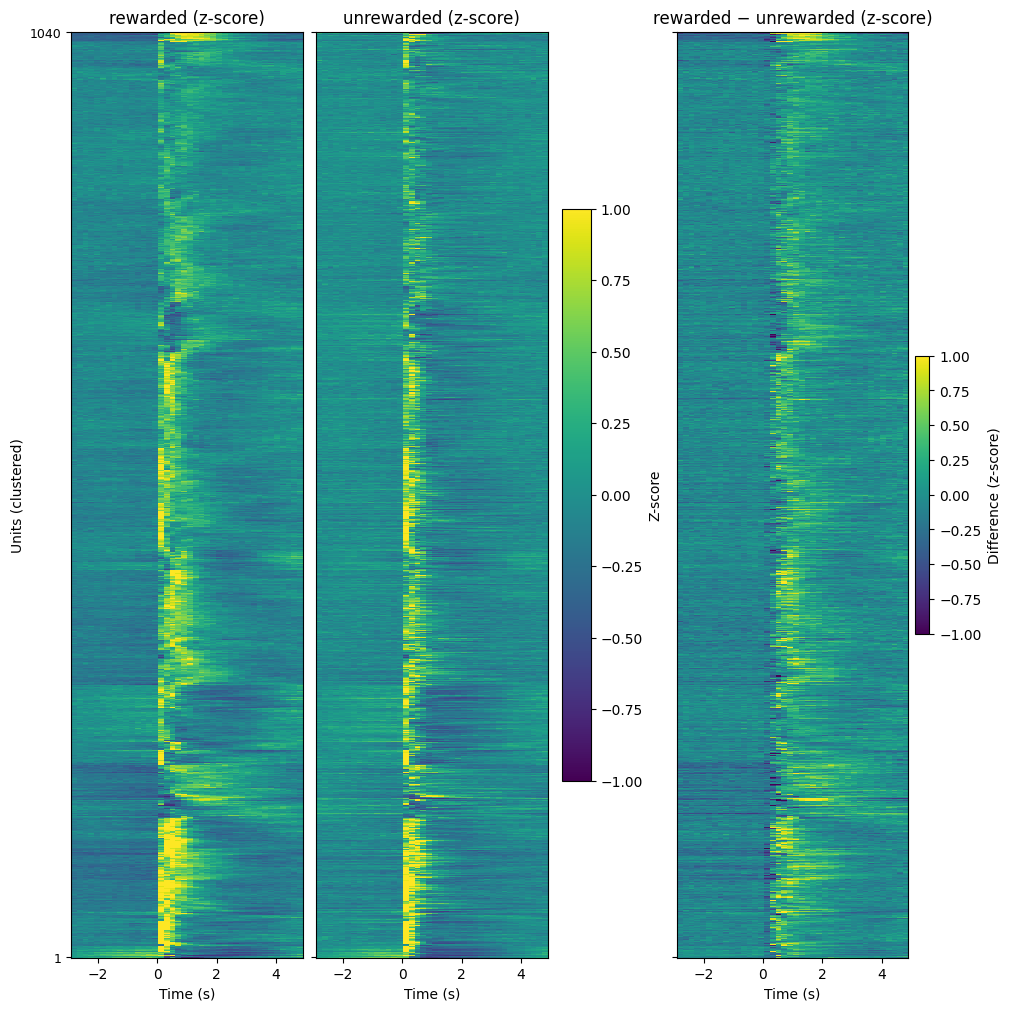

In [31]:
import importlib
import average_psth
from average_psth import load_psth_summary_zarr
importlib.reload(average_psth)

from average_psth import plot_psth_heatmaps_per_trial_type

psth_average = load_psth_summary_zarr("/root/capsule/scratch/average_psth/psth_summary_coef-simple_LR-QLearning_L2F1_softmax-reward-g0-s0-d0_tw-0.3_2_alpha-0.05_regions-MD_sign-positive.zarr")

# Use z-scored PSTH, averaged across all trial types
plot_psth_heatmaps_per_trial_type(
    psth_average,
    use_zscore=True,
    cluster_method="average",
    metric="euclidean",
    figsize=(10, 10),
    cmap="viridis",
    color_range=[-1,1],
    show_difference=True,
    difference_color_range=(-1, 1),
    show_unit_labels=True
)





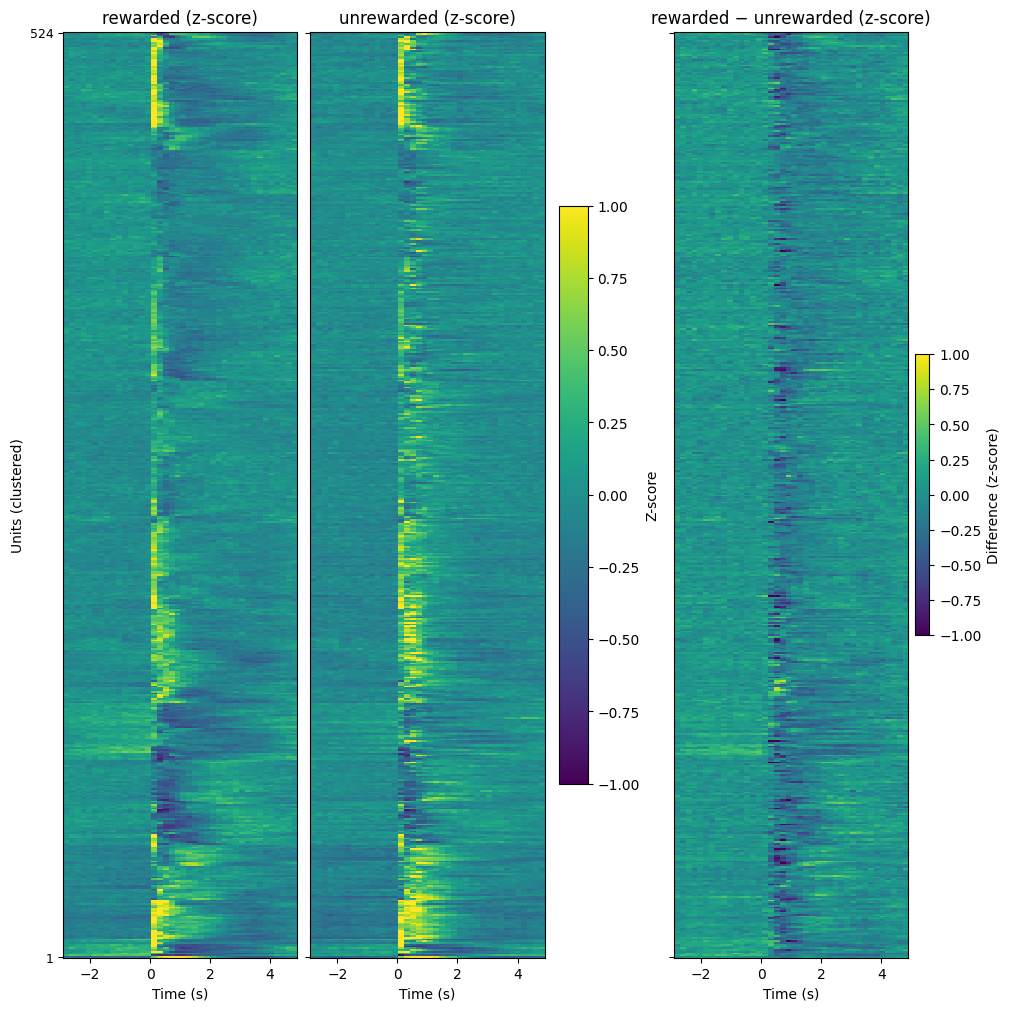

In [30]:
import importlib
import average_psth
from average_psth import load_psth_summary_zarr
importlib.reload(average_psth)

from average_psth import plot_psth_heatmaps_per_trial_type

psth_average = load_psth_summary_zarr("/root/capsule/scratch/average_psth/psth_summary_coef-simple_LR-QLearning_L2F1_softmax-reward-g0-s0-d0_tw-0.3_2_alpha-0.05_regions-MD_sign-negative.zarr")

# Use z-scored PSTH, averaged across all trial types
plot_psth_heatmaps_per_trial_type(
    psth_average,
    use_zscore=True,
    cluster_method="average",
    metric="euclidean",
    figsize=(10, 10),
    cmap="viridis",
    color_range=[-1,1],
    show_difference=True,
    difference_color_range=(-1, 1),
    show_unit_labels=True
)





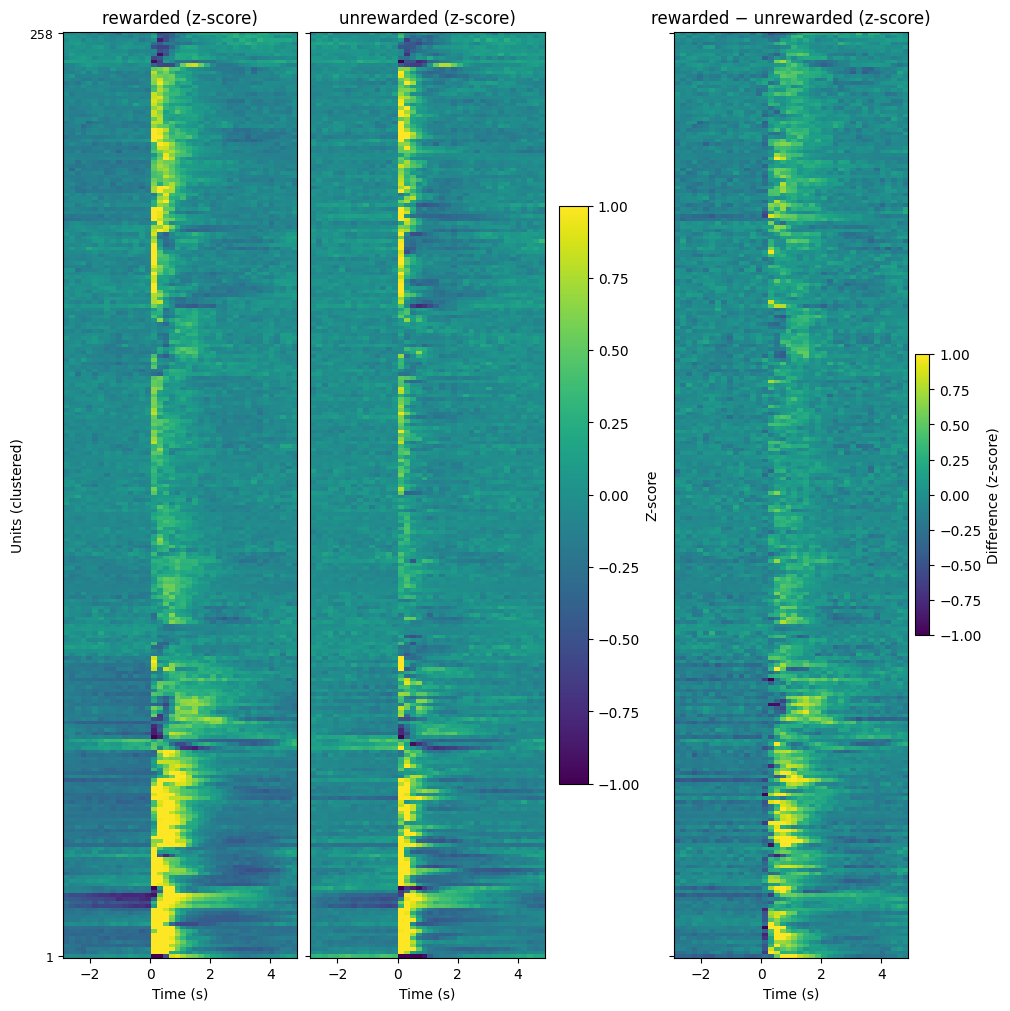

In [29]:
import importlib
import average_psth
from average_psth import load_psth_summary_zarr
importlib.reload(average_psth)

from average_psth import plot_psth_heatmaps_per_trial_type

psth_average = load_psth_summary_zarr("/root/capsule/scratch/average_psth/psth_summary_coef-simple_LR-QLearning_L2F1_softmax-reward-g0-s0-d0_tw-0.3_2_alpha-0.05_regions-SI-MA_sign-positive.zarr")

# Use z-scored PSTH, averaged across all trial types
plot_psth_heatmaps_per_trial_type(
    psth_average,
    use_zscore=True,
    cluster_method="average",
    metric="euclidean",
    figsize=(10, 10),
    cmap="viridis",
    color_range=[-1,1],
    show_difference=True,
    difference_color_range=(-1, 1),
    show_unit_labels=True
)





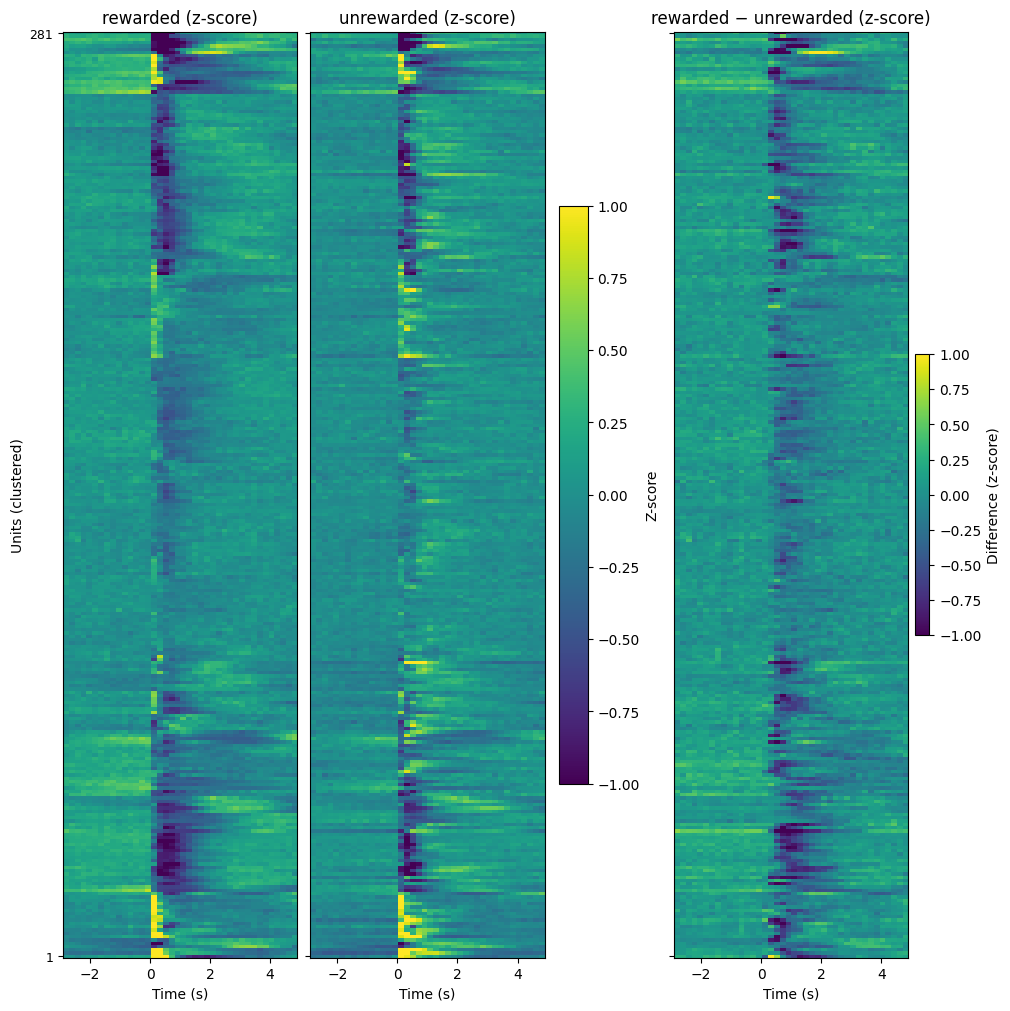

In [28]:
import importlib
import average_psth
from average_psth import load_psth_summary_zarr
importlib.reload(average_psth)

from average_psth import plot_psth_heatmaps_per_trial_type

psth_average = load_psth_summary_zarr("/root/capsule/scratch/average_psth/psth_summary_coef-simple_LR-QLearning_L2F1_softmax-reward-g0-s0-d0_tw-0.3_2_alpha-0.05_regions-SI-MA_sign-negative.zarr")

# Use z-scored PSTH, averaged across all trial types
plot_psth_heatmaps_per_trial_type(
    psth_average,
    use_zscore=True,
    cluster_method="average",
    metric="euclidean",
    figsize=(10, 10),
    cmap="viridis",
    color_range=[-1,1],
    show_difference=True,
    difference_color_range=(-1, 1),
    show_unit_labels=True
)



